In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.dropna(inplace=True)
df.shape

(714, 3)

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.describe()

,Survived,Age,Fare
count,714.000000,714.000000,714.000000
mean,0.406162,29.699118,34.694514
std,0.491460,14.526497,52.918930
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,8.050000
50%,0.000000,28.000000,15.741700
75%,1.000000,38.000000,33.375000
max,1.000000,80.000000,512.329200


In [6]:
X= df.iloc[:,1:]
y= df.iloc[:,0]

In [7]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [8]:
clf = DecisionTreeClassifier()
clf.fit (X_train, y_train)
y_pred= clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

In [9]:
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

np.float64(0.6316705790297339)

# Binning on Age and Fare columns using KBinsDiscretizer:

In [10]:
kbin_age= KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [11]:
trf= ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [12]:
X_train_trf= trf.fit_transform(X_train)
X_test_trf= trf.transform(X_test)

In [13]:
print(trf.named_transformers_['first'].bin_edges_[0])
print(trf.named_transformers_['second'].bin_edges_[0])

[ 0.42  6.   16.   19.   21.   23.   25.   28.   30.   32.   35.   38.
 42.   47.   54.   80.  ]
[  0.       7.25     7.775    7.8958   8.1583  10.5     13.      14.4542
  18.75    26.      26.55    31.275   51.4792  76.2917 108.9    512.3292]


In [14]:
output= pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [15]:
output.head()

,age,age_trf,fare,fare_trf
328,31.0,8.0,20.5250,8.0
73,26.0,6.0,14.4542,7.0
253,30.0,8.0,16.1000,7.0
719,33.0,9.0,7.7750,2.0
666,25.0,6.0,13.0000,6.0


In [16]:
output['age_labels']= pd.cut(x=X_train['Age'],bins= trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']= pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [17]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
678,43.0,12.0,46.900,11.0,"(42.0, 47.0]","(31.275, 51.479]"
805,31.0,8.0,7.775,2.0,"(30.0, 32.0]","(7.25, 7.775]"
247,24.0,5.0,14.500,7.0,"(23.0, 25.0]","(14.454, 18.75]"
812,35.0,10.0,10.500,5.0,"(32.0, 35.0]","(8.158, 10.5]"
322,30.0,8.0,12.350,5.0,"(28.0, 30.0]","(10.5, 13.0]"


# Function for Binning:

In [18]:
clf= DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2= clf.predict(X_test_trf)
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [19]:
X_trf= trf.fit_transform(X)
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

np.float64(0.6330985915492957)

In [20]:
def discretize(bins,strategy):
    kbin_age= KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare= KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    trf= ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[0])  
    ])
    X_trf=trf.fit_transform(X)
    print(np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")
    
    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")
    
    plt.show()
    
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")
    
    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("After")
    
    plt.show()

0.6331181533646322


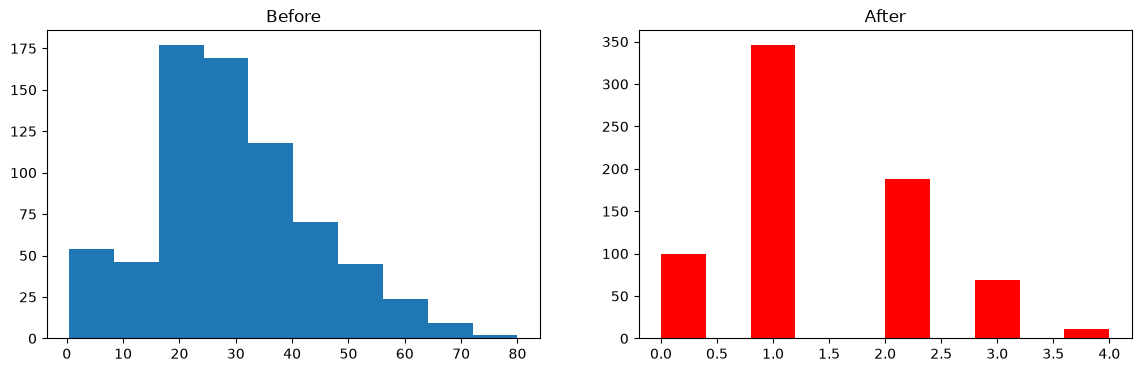

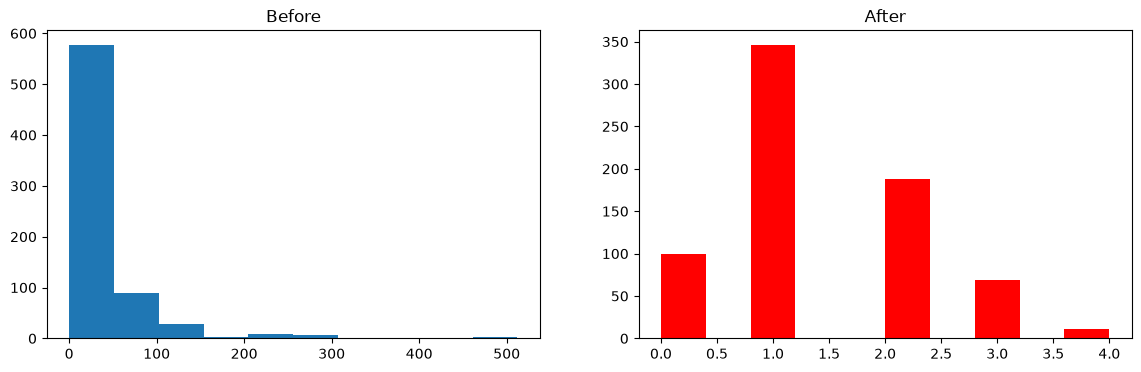

In [21]:
discretize(5,'uniform')

0.6373043818466353


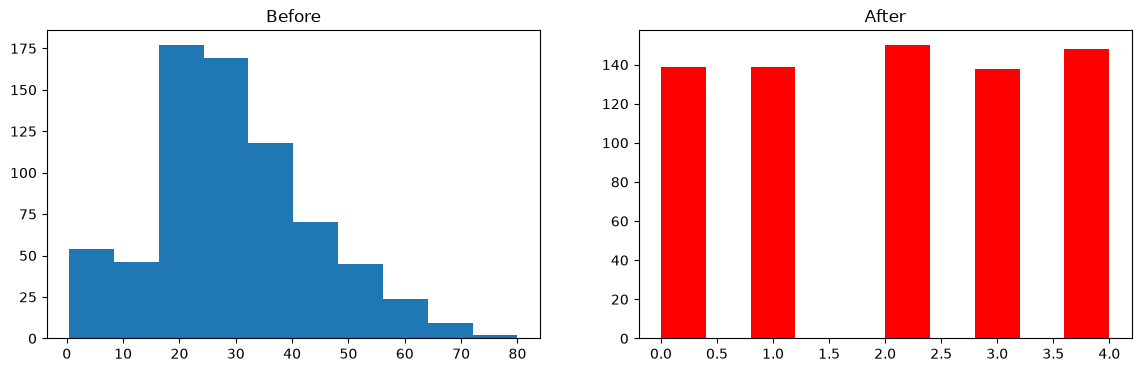

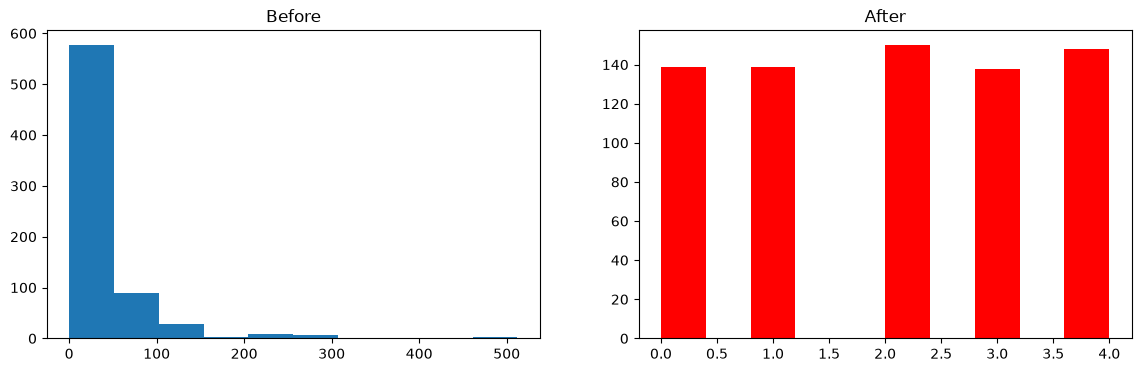

In [22]:
discretize(5,'quantile')

0.6275234741784036


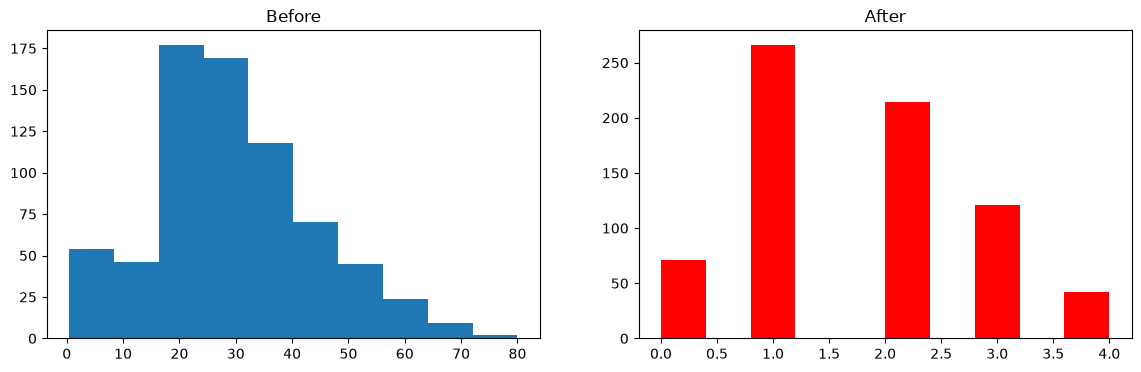

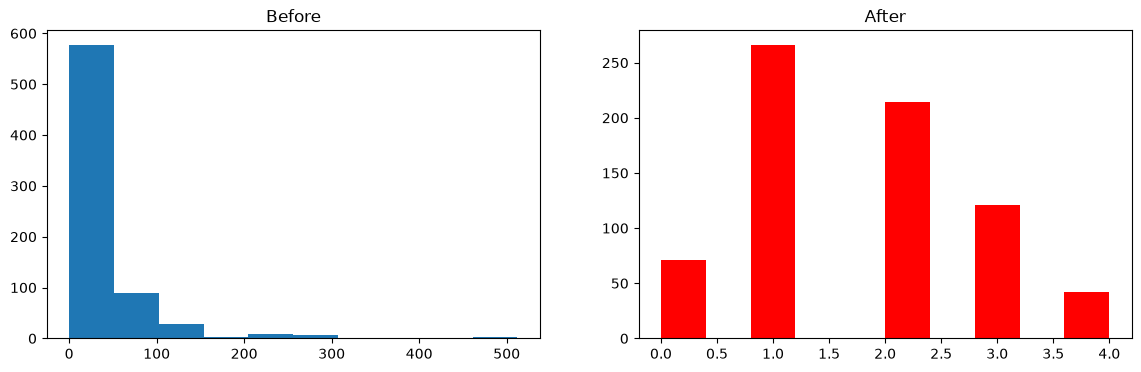

In [23]:
discretize(5,'kmeans')